In [2]:
# import all the packages and files
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import lognorm


fut1_check = pd.read_csv('cleanfut1.csv',)
fut2_check = pd.read_csv('cleanfut2.csv',)
fut3_check = pd.read_csv('cleanfut3.csv',)
fut4_check = pd.read_csv('cleanfut4.csv',)


futs = [fut1_check, fut2_check, fut3_check, fut4_check]

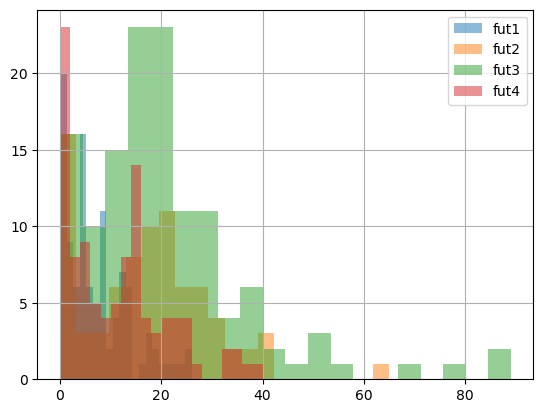

In [ ]:
beers = [["Grøn", "FF", "Guld", "Harboe"],
         ["GrønTuborg/TuborgClassic", "FineFestival/GuldTuborg"],
         ["Grøn", "Busøl", "GT", "Classic", "FineFestival"],
         ["Grøn", "Classic", "F-Festival"]]

all_beer_data = []
for fut, beer in zip(futs, beers):

    beer_cols = fut.columns.intersection(beer)

    beer_data = fut[beer_cols].astype(float).sum(axis=1)
    # print(beer_data.head())
    beer_data.hist(bins=20, alpha=0.5)

    all_beer_data.append(beer_data)

plt.legend(['fut1', 'fut2', 'fut3', 'fut4'])


plt.show()


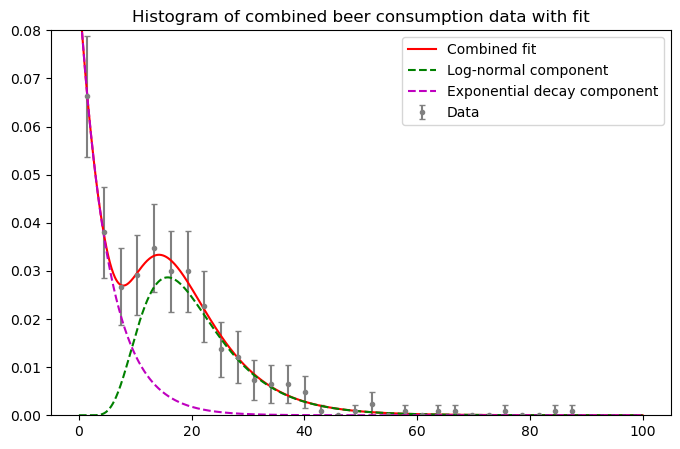

In [8]:
plt.figure(figsize=(8,5))

all_beer_data_df = pd.concat(all_beer_data,)

all_beer_data_df_no_zeros = all_beer_data_df[all_beer_data_df > -1]



bins, edges = np.histogram(all_beer_data_df_no_zeros, bins=30, density=True)
x = (edges[:-1] + edges[1:]) / 2
# plt.plot(x, bins, 'bo')

yerr = np.sqrt(bins/len(all_beer_data_df_no_zeros))
plt.errorbar(x, bins, yerr=yerr, fmt='.', color = "grey", label='Data', linestyle='none', capsize=2)

# fit the histogram to a log-normal distribution + an exponential decay

def exp_decay(x, a, decay):
    return a * np.exp(decay * x)

def lognorm_func(x, s, scale, a):
    return a * lognorm.pdf(x, s, scale=scale)

def lognorm_plus_exp(x, s, scale, a, b, decay):
    return lognorm_func(x, s, scale, a) + exp_decay(x, b, decay)

from scipy.optimize import curve_fit

popt, pcov = curve_fit(lognorm_plus_exp, x, bins, p0=[1, 10, 1, 0.1, -0.5],)
xx = np.linspace(0, 100, 1000)
pdf_fitted = lognorm_plus_exp(xx, *popt)

lognorm_fit = lognorm_func(xx, popt[0], popt[1], popt[2])
decay_fit = exp_decay(xx, popt[3], popt[4])


plt.plot(xx, pdf_fitted, 'r-', label='Combined fit')
plt.plot(xx, lognorm_fit, 'g--', label='Log-normal component')
plt.plot(xx, decay_fit, 'm--', label='Exponential decay component')

plt.title('Histogram of combined beer consumption data with fit')
plt.legend()

plt.ylim(0.,0.08)
# plt.plot(x, pdf_fitted*300, 'r-')


plt.show()